# This notebook includes initial exploration of modeling algorithms, particularly, using ensemble models such as RandomForest and XGBoost.
# It has not been updated with the final details of the main modeling notebook, but it still gives some insights in those methods.

# Dataset loading

In [380]:
# Loading the training/validation data and test data
import pandas as pd
owc2008_table4_all = pd.read_csv('datasets/owc2008_table4_456.csv')
owc2008_tableS2 = pd.read_csv('datasets/owc2008_tableS2_cleaned.csv')
owc2008_table4_all.head(10)

,duplex_id,sequence_5to3,length_bp,monovalent_mM,Mg2+_mM,Tm_C
0,ODN1,TTCTACCTATGTGAT,15,1,0.5,43.3
1,ODN1,TTCTACCTATGTGAT,15,1,1.5,46.1
2,ODN1,TTCTACCTATGTGAT,15,1,3.0,47.8
3,ODN1,TTCTACCTATGTGAT,15,1,10.0,50.2
4,ODN1,TTCTACCTATGTGAT,15,1,20.0,50.4
5,ODN1,TTCTACCTATGTGAT,15,5,0.5,42.1
6,ODN1,TTCTACCTATGTGAT,15,5,1.5,45.6
7,ODN1,TTCTACCTATGTGAT,15,5,3.0,47.6
8,ODN1,TTCTACCTATGTGAT,15,5,10.0,49.5
9,ODN1,TTCTACCTATGTGAT,15,5,20.0,50.4


In [381]:
# Drop the duplex_id column since it is captured anyway through the sequence column
# Drop the length_bp column since it will be part of features engineering later on and we want to keep the training/validation data as raw as possible for now
owc2008_table4_all.drop(columns=['duplex_id', 'length_bp'], inplace=True)
owc2008_table4_all.head(10)

,sequence_5to3,monovalent_mM,Mg2+_mM,Tm_C
0,TTCTACCTATGTGAT,1,0.5,43.3
1,TTCTACCTATGTGAT,1,1.5,46.1
2,TTCTACCTATGTGAT,1,3.0,47.8
3,TTCTACCTATGTGAT,1,10.0,50.2
4,TTCTACCTATGTGAT,1,20.0,50.4
5,TTCTACCTATGTGAT,5,0.5,42.1
6,TTCTACCTATGTGAT,5,1.5,45.6
7,TTCTACCTATGTGAT,5,3.0,47.6
8,TTCTACCTATGTGAT,5,10.0,49.5
9,TTCTACCTATGTGAT,5,20.0,50.4


# Models and Metrics

As introduced in the EDA notebook, our goal is two fold
1. We would like to acheieve high predicition accuracy with a limited number of data points.
2. We *hope* to have a simple/interpretable model that captures the most biophysically relevant dependencies of the melting temperature.

To handle the first point, we will be using **Mean Absolute Error (MAE)** as our metric since it was the main metric used by the prior studies (Owc-2004 and Owc-2008).\
Also, given the limited number of data points and the target accuracy, I think it will be best to use models that handle such scenarios right away. **In particular, we will compare XGboost and RandomForestRegressor.** Given the EDA we did in the EDA notebook, non-linear dependencies and salt interactions seem unavoidable, so these models would be perfect in capturing such complexity.

To investigate the second point, we will test the two models on multiple variations of the dataset each with **a different set of features (Features Engineering)** to find the minimal set of features needed. This will help us narrow down the most important features and potential salt interactions between them.
The point of intepretability/simplicity is a challenge that we will try to handle primarily in this way, but hopefully we will obtain some useful insights along the way.

# Features engineering

We will test different sets of features to select the most important ones.\
**The best performing model would be the best in terms of the number of features and the MAE score (lower=better for both).**

As explored in the EDA notebook, we found that the melting temperature is highly dependent on GC-content, Duplex Length, and Log[Salt], but it will be nice to see how good a model that has other features engineered is.

To this end, we will compare the models performance on four sets of features:
1. *The naive set of features - our baseline model*: This will just include the number of nucleotides (A,T,C,G) and the salt concentrations in mM. 
2. *The typical set of features*: Instead of the number of nucleotides, we will use the GC-content and duplex length. **(They are linearly dependent, so it is redundunt to keep both)**
3. *The typical set of features with log-transformations*: Similar to the previous one, but using Log[Salt (M)] instead of Salt concentration in mM right away. This is motivated by our EDA and prior experimental and modeling studies of salt dependency of melting temperatures.
3. *The modern set of features*: Using only the number of the ten different dinucleotide steps (AA/TT, GC/CG, AC/GT, ...) with the two terminal contributions to capture the suggestion of the more recent papers (Unzip-2010 and Unzip-2017).


## 1.1 Typical set of features

In [382]:
salt_baseline_features = ['monovalent_mM', 'Mg2+_mM']
sequence_baseline_features = ['length_bp', 'GC_content']

typical_features_no_salt_interaction = salt_baseline_features + sequence_baseline_features

# Add length_bp and GC-content columns
owc2008_table4_all['length_bp'] = owc2008_table4_all['sequence_5to3'].apply(len)
owc2008_table4_all['GC_content'] = owc2008_table4_all['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0)

# Do the same thing for the test data
owc2008_tableS2['length_bp'] = owc2008_tableS2['sequence_5to3'].apply(len)
owc2008_tableS2['GC_content'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: (seq.count('G') + seq.count('C')) / len(seq) if len(seq) > 0 else 0)

owc2008_table4_all.sample(10)

,sequence_5to3,monovalent_mM,Mg2+_mM,Tm_C,length_bp,GC_content
311,CAGTGGGCTCCTGGGCGTGCTGGTC,5,3.0,76.6,25,0.720000
31,TTCTACCTATGTGAT,605,10.0,51.9,15,0.333333
9,TTCTACCTATGTGAT,5,20.0,50.4,15,0.333333
367,CTTAAGATATGAGAACTTCAACTAATGTGT,105,125.0,67.2,30,0.300000
258,GTTCTATACTCTTGAAGTTGATTAC,605,1.5,66.2,25,0.320000
271,CTGGTCTGGATCTGAGAACTTCAGG,5,0.5,65.1,25,0.520000
79,CAGCCTCGTCGCAGC,1,10.0,66.8,15,0.733333
273,CTGGTCTGGATCTGAGAACTTCAGG,5,3.0,68.5,25,0.520000
380,AGTCTGGTCTGGATCTGAGAACTTCAGGCT,1,0.5,69.8,30,0.500000
4,TTCTACCTATGTGAT,1,20.0,50.4,15,0.333333


## 1.2 Typical set of features (with salt interactions)

In [383]:
import numpy as np

typical_features_with_salt_interaction = typical_features_no_salt_interaction.copy()
# Add salt interaction features to the DataFrame
for salt in salt_baseline_features:
    for feature in sequence_baseline_features:
        owc2008_table4_all[f'{salt}-{feature}'] = owc2008_table4_all[salt] * owc2008_table4_all[feature]
        # Similarly, we can also add the interaction features to the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[feature]
        typical_features_with_salt_interaction.append(f'{salt}-{feature}')

owc2008_table4_all[typical_features_with_salt_interaction].head(10)

,monovalent_mM,Mg2+_mM,length_bp,GC_content,monovalent_mM-length_bp,monovalent_mM-GC_content,Mg2+_mM-length_bp,Mg2+_mM-GC_content
0,1,0.5,15,0.333333,15,0.333333,7.5,0.166667
1,1,1.5,15,0.333333,15,0.333333,22.5,0.500000
2,1,3.0,15,0.333333,15,0.333333,45.0,1.000000
3,1,10.0,15,0.333333,15,0.333333,150.0,3.333333
4,1,20.0,15,0.333333,15,0.333333,300.0,6.666667
5,5,0.5,15,0.333333,75,1.666667,7.5,0.166667
6,5,1.5,15,0.333333,75,1.666667,22.5,0.500000
7,5,3.0,15,0.333333,75,1.666667,45.0,1.000000
8,5,10.0,15,0.333333,75,1.666667,150.0,3.333333
9,5,20.0,15,0.333333,75,1.666667,300.0,6.666667


## 2.1 Naive set of features

In [384]:
naive_baseline_features = ['f_A', 'f_G', 'f_C', 'length_bp']
naive_features_no_salt_interaction = naive_baseline_features + salt_baseline_features

# Add the counts of each nucleotide as features
for nucleotide in ['A', 'G', 'C']:
    owc2008_table4_all[f'f_{nucleotide}'] = owc2008_table4_all['sequence_5to3'].apply(lambda seq: seq.count(nucleotide)/len(seq) if len(seq) > 0 else 0)
    # Do the same thing for the test data
    owc2008_tableS2[f'f_{nucleotide}'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: seq.count(nucleotide)/len(seq) if len(seq) > 0 else 0)

owc2008_table4_all[naive_features_no_salt_interaction].head(10)

,f_A,f_G,f_C,length_bp,monovalent_mM,Mg2+_mM
0,0.2,0.133333,0.2,15,1,0.5
1,0.2,0.133333,0.2,15,1,1.5
2,0.2,0.133333,0.2,15,1,3.0
3,0.2,0.133333,0.2,15,1,10.0
4,0.2,0.133333,0.2,15,1,20.0
5,0.2,0.133333,0.2,15,5,0.5
6,0.2,0.133333,0.2,15,5,1.5
7,0.2,0.133333,0.2,15,5,3.0
8,0.2,0.133333,0.2,15,5,10.0
9,0.2,0.133333,0.2,15,5,20.0


## 2.2 Naive set of features (with salt interaction)

In [385]:
naive_features_with_salt_interaction = naive_features_no_salt_interaction.copy() 

for salt in salt_baseline_features:
    for feature in naive_baseline_features:
        owc2008_table4_all[f'{salt}-{feature}'] = owc2008_table4_all[salt] * owc2008_table4_all[f'{feature}']
        naive_features_with_salt_interaction.append(f'{salt}-{feature}')
        # Do the same thing for the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[f'{feature}']


owc2008_table4_all[naive_features_with_salt_interaction].head(10)

,f_A,f_G,f_C,length_bp,monovalent_mM,Mg2+_mM,monovalent_mM-f_A,monovalent_mM-f_G,monovalent_mM-f_C,monovalent_mM-length_bp,Mg2+_mM-f_A,Mg2+_mM-f_G,Mg2+_mM-f_C,Mg2+_mM-length_bp
0,0.2,0.133333,0.2,15,1,0.5,0.2,0.133333,0.2,15,0.1,0.066667,0.1,7.5
1,0.2,0.133333,0.2,15,1,1.5,0.2,0.133333,0.2,15,0.3,0.200000,0.3,22.5
2,0.2,0.133333,0.2,15,1,3.0,0.2,0.133333,0.2,15,0.6,0.400000,0.6,45.0
3,0.2,0.133333,0.2,15,1,10.0,0.2,0.133333,0.2,15,2.0,1.333333,2.0,150.0
4,0.2,0.133333,0.2,15,1,20.0,0.2,0.133333,0.2,15,4.0,2.666667,4.0,300.0
5,0.2,0.133333,0.2,15,5,0.5,1.0,0.666667,1.0,75,0.1,0.066667,0.1,7.5
6,0.2,0.133333,0.2,15,5,1.5,1.0,0.666667,1.0,75,0.3,0.200000,0.3,22.5
7,0.2,0.133333,0.2,15,5,3.0,1.0,0.666667,1.0,75,0.6,0.400000,0.6,45.0
8,0.2,0.133333,0.2,15,5,10.0,1.0,0.666667,1.0,75,2.0,1.333333,2.0,150.0
9,0.2,0.133333,0.2,15,5,20.0,1.0,0.666667,1.0,75,4.0,2.666667,4.0,300.0


## 3.1 Modern set of features

In [386]:
# The ten dinucleotide with 2 terminal factors ('AA/TT', 'AT/TA', 'TA/AT', 'CA/GT', 'GT/CA', 'CT/GA', 'GA/CT', 'CG/GC', 'GC/CG', 'GG/CC', 'Terminal_A/T', 'Terminal_G/C') frequency features
dinucleotide_step = ['AA/TT', 'AT/TA', 'TA/AT', 'CA/GT', 'GT/CA', 'CT/GA', 'GA/CT', 'CG/GC', 'GC/CG', 'GG/CC']
terminal_step = ['Terminal_A/T', 'Terminal_G/C']
dinucleotide_steps = dinucleotide_step #+ terminal_step
dinucleotide_freq = [f'f_{dinucleotide}' for dinucleotide in dinucleotide_steps]

def calculate_dinucleotide_frequencies(seq):
    frequencies = {}

    canonical_map = {
        'AA': 'AA/TT', 'TT': 'AA/TT',
        'AT': 'AT/TA',
        'TA': 'TA/AT',
        'CA': 'CA/GT', 'TG': 'CA/GT',
        'GT': 'GT/CA', 'AC': 'GT/CA',
        'CT': 'CT/GA', 'AG': 'CT/GA',
        'GA': 'GA/CT', 'TC': 'GA/CT',
        'CG': 'CG/GC',
        'GC': 'GC/CG',
        'GG': 'GG/CC', 'CC': 'GG/CC',
    }

    # Generate dinucleotide pairs
    dinucleotide_pairs = [canonical_map.get(seq[i:i+2], None) for i in range(len(seq) - 1) if seq[i:i+2] in canonical_map]

    # Count the frequencies of each dinucleotide pair
    for pair in dinucleotide_pairs:
        frequencies[pair] = frequencies.get(pair, 0) + 1

    # Calculate terminal nucleotide frequencies (count A and T as Terminal_A/T, count G and C as Terminal_G/C)
    if len(seq) > 0:
        if seq[0] in ['A', 'T']:
            frequencies['Terminal_A/T'] = frequencies.get('Terminal_A/T', 0) + 1
        else:
            frequencies['Terminal_G/C'] = frequencies.get('Terminal_G/C', 0) + 1
        if seq[-1] in ['A', 'T']:
            frequencies['Terminal_A/T'] = frequencies.get('Terminal_A/T', 0) + 1
        else:
            frequencies['Terminal_G/C'] = frequencies.get('Terminal_G/C', 0) + 1 

    return frequencies


# Test the dinucleotide frequency function with a dataframe format
dinucleotide_tests = {}

for seq in owc2008_table4_all['sequence_5to3'].unique():
    test_freqs = calculate_dinucleotide_frequencies(seq)

    # Quick check 1: The sum of all dinucleotide frequencies should equal the duplex length + 1
    check_1 = sum(test_freqs.values()) == len(seq) + 1
    
    dinucleotide_tests[seq] = {
        'Sum frequencies = Duplex length + 1?': check_1}
    
    # Show the calculated frequencies for each sequence
    for dinucleotide in dinucleotide_steps:
        dinucleotide_tests[seq][f'F_{dinucleotide}'] = test_freqs.get(dinucleotide, 0)
    
# Convert to DataFrame with sequences as columns and checks as rows
dinucleotide_tests_df = pd.DataFrame(dinucleotide_tests)
display(dinucleotide_tests_df.T)


,Sum frequencies = Duplex length + 1?,F_AA/TT,F_AT/TA,F_TA/AT,F_CA/GT,F_GT/CA,F_CT/GA,F_GA/CT,F_CG/GC,F_GC/CG,F_GG/CC
TTCTACCTATGTGAT,True,1,2,2,2,2,2,2,0,0,1
GCAGTGGATGTGAGA,True,0,1,0,4,2,2,3,0,1,1
CAGCCTCGTCGCAGC,True,0,0,0,2,1,3,2,2,3,1
TGATTCTACCTATGTGATTT,True,3,3,2,3,2,2,3,0,0,1
AGCTGCAGTGGATGTGAGAA,True,1,1,0,5,2,4,3,0,2,1
CAGCCTCGTTCGCACAGCCC,True,1,0,0,3,2,3,2,2,3,3
GTTCTATACTCTTGAAGTTGATTAC,True,5,2,3,2,4,4,4,0,0,0
CTGGTCTGGATCTGAGAACTTCAGG,True,2,1,0,4,2,6,6,0,0,3
CAGTGGGCTCCTGGGCGTGCTGGTC,True,0,0,0,5,3,4,2,1,3,6
CTTAAGATATGAGAACTTCAACTAATGTGT,True,6,3,3,4,4,5,4,0,0,0


In [387]:
# def count_dinucleotides(sequence):
#     """
#     Count nearest-neighbor dinucleotide steps in a DNA sequence.

#     The 10 unique dinucleotide pairs (SantaLucia nearest-neighbor model):
#       AA/TT, AT/TA, TA/AT, CA/GT, GT/CA, CT/GA, GA/CT, CG/GC, GC/CG, GG/CC

#     Parameters
#     ----------
#     sequence : str – DNA sequence (5'->3')

#     Returns
#     -------
#     dict : counts for each of the 10 dinucleotide steps
#     """

#     sequence = sequence.upper()

#     # Explicit mapping of all 16 possible dinucleotides to their canonical label.
#     # Logic: dinucleotide XY on top strand pairs with comp(Y)comp(X) on bottom (5'->3').
#     # Self-complementary pairs share a label; distinct pairs have separate labels.
#     #
#     #  AA <-> TT  => AA/TT  (same label)
#     #  AT <-> AT  => AT/TA  (same label, self-complementary)
#     #  TA <-> TA  => TA/AT  (same label, self-complementary)
#     #  GG <-> CC  => GG/CC  (same label)
#     #
#     #  CA <-> TG ... no: comp(A)comp(C) = TG, but TG is NOT in the 10 labels.
#     #  Let's be precise: for CA on top, bottom strand 5'->3' is comp(A)comp(C) = TG.
#     #  But the label is written as top/bottom = CA/GT.
#     #  Wait — bottom strand of 5'-CA-3' is 3'-GT-5', which read 5'->3' is TG.
#     #  The convention in the paper is: XY/X'Y' where X'Y' is the bottom strand
#     #  written 3'->5' (i.e., directly below the top strand), NOT reversed.
#     #  So CA/GT means: top 5'-CA-3' paired with bottom 3'-GT-5'.
#     #  The reverse case GT/CA means: top 5'-GT-3' paired with bottom 3'-CA-5'.
#     #  These are distinct because CA != GT.

#     canonical_map = {
#         # Self-complementary pairs (XY and its complement map to same label)
#         'AA': 'AA/TT',
#         'TT': 'AA/TT',
#         'AT': 'AT/TA',
#         'TA': 'TA/AT',
#         'GG': 'GG/CC',
#         'CC': 'GG/CC',

#         # Distinct pairs
#         'CA': 'CA/GT',
#         'GT': 'GT/CA',
#         'CT': 'CT/GA',
#         'GA': 'GA/CT',
#         'CG': 'CG/GC',
#         'GC': 'GC/CG',

#         # Remaining dinucleotides — their complements are already listed above
#         # AC: complement pair is GT/CA, bottom of AC is GT read 3'->5' => GT/CA? 
#         # Let's verify: top 5'-AC-3', bottom 3'-TG-5'. Written as AC/TG — but TG
#         # is not one of the 10. By symmetry AC is the same as GT/CA read backwards,
#         # i.e., the complement duplex of GT/CA is AC/TG = CA/GT reversed => GT/CA.
#         # Simpler: just verify all 16 are covered by checking complement pairs.
#         'AC': 'GT/CA',   # complement of GT/CA (top GT -> bottom CA, flip: top AC -> bottom TG, same duplex)
#         'TG': 'CA/GT',   # complement of CA/GT
#         'AG': 'CT/GA',   # complement of CT/GA
#         'TC': 'GA/CT',   # complement of GA/CT
#         'GC': 'GC/CG',   # already listed
#         'CG': 'CG/GC',   # already listed
#     }

#     # Cleaner — just define all 16 unambiguously:
#     canonical_map = {
#         'AA': 'AA/TT', 'TT': 'AA/TT',
#         'AT': 'AT/TA',
#         'TA': 'TA/AT',
#         'CA': 'CA/GT', 'TG': 'CA/GT',
#         'GT': 'GT/CA', 'AC': 'GT/CA',
#         'CT': 'CT/GA', 'AG': 'CT/GA',
#         'GA': 'GA/CT', 'TC': 'GA/CT',
#         'CG': 'CG/GC',
#         'GC': 'GC/CG',
#         'GG': 'GG/CC', 'CC': 'GG/CC',
#     }

#     counts = {label: 0 for label in [
#         'AA/TT', 'AT/TA', 'TA/AT', 'CA/GT', 'GT/CA',
#         'CT/GA', 'GA/CT', 'CG/GC', 'GC/CG', 'GG/CC'
#     ]}

#     for i in range(len(sequence) - 1):
#         dinuc = sequence[i:i+2]
#         counts[canonical_map[dinuc]] += 1

#     return counts


# # --- Test ---
# if __name__ == "__main__":
#     seq = "CTTAAGATATGAGAACTTCAACTAATGTGT"
#     result = count_dinucleotides(seq)
#     total = sum(result.values())
#     print(f"Sequence : {seq}")
#     print(f"Length   : {len(seq)} nt  =>  {len(seq)-1} expected steps\n")
#     for label, count in result.items():
#         print(f"  {label}: {count}")
#     print(f"\n  Total steps counted: {total}")
#     assert total == len(seq) - 1, "BUG: total != len-1"
#     print("  ✓ Total matches len(seq)-1")

In [388]:
modern_baseline_features = ['length_bp']
modern_features_no_salt_interaction = ['length_bp'] + salt_baseline_features

# Add the dinucleotide frequency features 
for feature in dinucleotide_freq:
    owc2008_table4_all[f'{feature}'] = owc2008_table4_all['sequence_5to3'].apply(lambda seq: calculate_dinucleotide_frequencies(seq).get(feature[2:], 0)/len(seq) if len(seq) > 0 else 0)
    modern_features_no_salt_interaction.append(f'{feature}')
    modern_baseline_features.append(f'{feature}')
    # Do the same thing for the test data
    owc2008_tableS2[f'{feature}'] = owc2008_tableS2['sequence_5to3'].apply(lambda seq: calculate_dinucleotide_frequencies(seq).get(feature[2:], 0)/len(seq) if len(seq) > 0 else 0)

owc2008_table4_all[modern_features_no_salt_interaction].head(10)

,length_bp,monovalent_mM,Mg2+_mM,f_AA/TT,f_AT/TA,f_TA/AT,f_CA/GT,f_GT/CA,f_CT/GA,f_GA/CT,f_CG/GC,f_GC/CG,f_GG/CC
0,15,1,0.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
1,15,1,1.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
2,15,1,3.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
3,15,1,10.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
4,15,1,20.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
5,15,5,0.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
6,15,5,1.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
7,15,5,3.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
8,15,5,10.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667
9,15,5,20.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,0.0,0.0,0.066667


## 3.2 Modern features (with salt interaction)

In [389]:
# Interaction features between salt concentration and dinucleotide frequencies (Ignoring terminal dinucleotide features for now since they are more complex to interpret and may not have as strong of an interaction with salt concentration as the internal dinucleotide frequencies)
modern_features_with_salt_interaction = modern_features_no_salt_interaction.copy() 
for salt in salt_baseline_features:
    for feature in modern_baseline_features:
        owc2008_table4_all[f'{salt}-{feature}'] = owc2008_table4_all[salt] * owc2008_table4_all[f'{feature}']
        modern_features_with_salt_interaction.append(f'{salt}-{feature}')
        # Do the same thing for the test data
        owc2008_tableS2[f'{salt}-{feature}'] = owc2008_tableS2[salt] * owc2008_tableS2[f'{feature}']

owc2008_table4_all[modern_features_with_salt_interaction].head(10)

,length_bp,monovalent_mM,Mg2+_mM,f_AA/TT,f_AT/TA,f_TA/AT,f_CA/GT,f_GT/CA,f_CT/GA,f_GA/CT,...,Mg2+_mM-f_AA/TT,Mg2+_mM-f_AT/TA,Mg2+_mM-f_TA/AT,Mg2+_mM-f_CA/GT,Mg2+_mM-f_GT/CA,Mg2+_mM-f_CT/GA,Mg2+_mM-f_GA/CT,Mg2+_mM-f_CG/GC,Mg2+_mM-f_GC/CG,Mg2+_mM-f_GG/CC
0,15,1,0.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,0.033333,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.0,0.0,0.033333
1,15,1,1.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,0.100000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.0,0.0,0.100000
2,15,1,3.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,0.200000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.0,0.0,0.200000
3,15,1,10.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,0.666667,1.333333,1.333333,1.333333,1.333333,1.333333,1.333333,0.0,0.0,0.666667
4,15,1,20.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,1.333333,2.666667,2.666667,2.666667,2.666667,2.666667,2.666667,0.0,0.0,1.333333
5,15,5,0.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,0.033333,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.0,0.0,0.033333
6,15,5,1.5,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,0.100000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.0,0.0,0.100000
7,15,5,3.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,0.200000,0.400000,0.400000,0.400000,0.400000,0.400000,0.400000,0.0,0.0,0.200000
8,15,5,10.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,0.666667,1.333333,1.333333,1.333333,1.333333,1.333333,1.333333,0.0,0.0,0.666667
9,15,5,20.0,0.066667,0.133333,0.133333,0.133333,0.133333,0.133333,0.133333,...,1.333333,2.666667,2.666667,2.666667,2.666667,2.666667,2.666667,0.0,0.0,1.333333


In [390]:
typical_features_no_salt_interaction, typical_features_with_salt_interaction, naive_features_no_salt_interaction, naive_features_with_salt_interaction, modern_features_no_salt_interaction, modern_features_with_salt_interaction

(['monovalent_mM', 'Mg2+_mM', 'length_bp', 'GC_content'],
 ['monovalent_mM',
  'Mg2+_mM',
  'length_bp',
  'GC_content',
  'monovalent_mM-length_bp',
  'monovalent_mM-GC_content',
  'Mg2+_mM-length_bp',
  'Mg2+_mM-GC_content'],
 ['f_A', 'f_G', 'f_C', 'length_bp', 'monovalent_mM', 'Mg2+_mM'],
 ['f_A',
  'f_G',
  'f_C',
  'length_bp',
  'monovalent_mM',
  'Mg2+_mM',
  'monovalent_mM-f_A',
  'monovalent_mM-f_G',
  'monovalent_mM-f_C',
  'monovalent_mM-length_bp',
  'Mg2+_mM-f_A',
  'Mg2+_mM-f_G',
  'Mg2+_mM-f_C',
  'Mg2+_mM-length_bp'],
 ['length_bp',
  'monovalent_mM',
  'Mg2+_mM',
  'f_AA/TT',
  'f_AT/TA',
  'f_TA/AT',
  'f_CA/GT',
  'f_GT/CA',
  'f_CT/GA',
  'f_GA/CT',
  'f_CG/GC',
  'f_GC/CG',
  'f_GG/CC'],
 ['length_bp',
  'monovalent_mM',
  'Mg2+_mM',
  'f_AA/TT',
  'f_AT/TA',
  'f_TA/AT',
  'f_CA/GT',
  'f_GT/CA',
  'f_CT/GA',
  'f_GA/CT',
  'f_CG/GC',
  'f_GC/CG',
  'f_GG/CC',
  'monovalent_mM-length_bp',
  'monovalent_mM-f_AA/TT',
  'monovalent_mM-f_AT/TA',
  'monovalent_mM-f_TA/

# Models train/val for the different sets of features

Summary of features:
1. Naive features (monovalent_mM, Mg2+_mM, N_A, N_T, N_G, N_C)
2. Typical features (monovalent_mM, Mg2+_mM, length_bp, GC_content)
3. Typical features with log-transformed salt concentrations (log_monovalent_M, log_Mg2+_M, length_bp, GC_content)
4. Modern features (monovalent_mM, Mg2+_mM, AA/TT, AC/TG, AG/TC, AT/TA, CA/GT, CC/GG, CG/GC, GA/CT, GC/CG, TA/AT, Terminal A/T, Terminal G/C)

*Notes on dataset splitting*:\
We do kfold-validation with 10 splits (Validation set = 10%) since we have limited number of data points.\
Also, we stratify by sequence to ensure that all 12 unique sequences are represented in both the training and validation sets, and set random_state for reproducibility.\
As mentioned in the EDA notebook, the test set is a completely different datatset that we will use toward the end to compare to literature model of Owc-2008.

## Initial CV trials

In [ ]:
# Single validation set approach (10% of the data for validation, stratified)

# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb

# # Step 0: train/val split
# # We stratify by sequence to ensure that all 12 unique sequences are represented in both the training and validation sets, and set random_state for reproducibility
# train_data, val_data = train_test_split(owc2008_table4, test_size=0.1, random_state=614, shuffle=True, stratify=owc2008_table4['sequence_5to3']) # OOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOO-HIO

# # Step 1: Train both models on each training set
# all_features = {
#     'Naive': naive_features,
#     'Typical': typical_features_no_log,
#     'Typical with Log': typical_features_with_log,
#     'Modern': modern_features
# }

# rf_models = {all_features_name: RandomForestRegressor(random_state=614) for all_features_name in all_features.keys()}
# xgb_models = {all_features_name: xgb.XGBRegressor(random_state=614) for all_features_name in all_features.keys()}

# trained_models = {}

# for feature_set_name, feature_set in all_features.items():
#     print(f"Training models with {feature_set_name} features...")
    
#     # Train Random Forest model
#     rf_models[feature_set_name].fit(train_data[feature_set], train_data['Tm_C'])
    
#     # Train XGBoost model
#     xgb_models[feature_set_name].fit(train_data[feature_set], train_data['Tm_C'])
    
#     print(f"Models trained with {feature_set_name} features.\n")
    
#     trained_models[feature_set_name] = {'Random Forest': rf_models[feature_set_name], 'XGBoost': xgb_models[feature_set_name]}
# # Step 2: Evaluate the performance of each model on the validation set using MAE
# from sklearn.metrics import mean_absolute_error

# model_performance_train = {}
# model_performance_val = {}

# for feature_set_name, models in trained_models.items():
#     print(f"Evaluating models with {feature_set_name} features...")

#     rf_predicition_train = models['Random Forest'].predict(train_data[all_features[feature_set_name]])
#     xgb_prediction_train = models['XGBoost'].predict(train_data[all_features[feature_set_name]])
    
#     rf_predictions_val = models['Random Forest'].predict(val_data[all_features[feature_set_name]])
#     xgb_predictions_val = models['XGBoost'].predict(val_data[all_features[feature_set_name]])
    

#     rf_mae_train = mean_absolute_error(train_data['Tm_C'], rf_predicition_train)
#     xgb_mae_train = mean_absolute_error(train_data['Tm_C'], xgb_prediction_train)

#     rf_mae_val = mean_absolute_error(val_data['Tm_C'], rf_predictions_val)
#     xgb_mae_val = mean_absolute_error(val_data['Tm_C'], xgb_predictions_val)
    
#     model_performance_train[feature_set_name] = {'Random Forest MAE': rf_mae_train, 'XGBoost MAE': xgb_mae_train}
#     model_performance_val[feature_set_name] = {'Random Forest MAE': rf_mae_val, 'XGBoost MAE': xgb_mae_val}

#     print(f"Models evaluated with {feature_set_name} features.\n")
#     # print(f"Training - Random Forest MAE: {rf_mae_train:.4f} | XGBoost MAE: {xgb_mae_train:.4f}")
#     # print(f"Validation - Random Forest MAE: {rf_mae_val:.4f} | XGBoost MAE: {xgb_mae_val:.4f}\n")

# # DataFrame to summarize the performance of each model on the training and validation sets in one dataframe for easier comparison
# performance_summary_train = pd.DataFrame(model_performance_train).T
# performance_summary_val = pd.DataFrame(model_performance_val).T

# # Show side by side comparison of training and validation performance for each feature set (columns: xg-train, xg-val, rf-train, rf-val)
# performance_comparison = pd.DataFrame({
#     'Random Forest Train MAE': performance_summary_train['Random Forest MAE'],
#     'Random Forest Val MAE': performance_summary_val['Random Forest MAE'],
#     'XGBoost Val MAE': performance_summary_val['XGBoost MAE'],
#     'XGBoost Train MAE': performance_summary_train['XGBoost MAE']
# })

# performance_comparison

In [ ]:
# Initial K-Fold Cross-Validation approach (10 folds, stratified by sequence)
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import mean_absolute_error
# import numpy as np
# from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb

# # Step 0: Set up 10-fold cross-validation
# kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=614)

# # Step 1: Train and evaluate models using K-Fold
# all_features = {
#     'Naive': naive_features,
#     'Typical': typical_features_no_log,
#     'Typical with Log': typical_features_with_log,
#     'Modern': modern_features
# }
# models_names = ['Random Forest', 'XGBoost']
# splits_names = ['Training', 'Validation']
# best_overall_models = {feature: {"RF": (None, float('inf')), "XGBoost": (None, float('inf'))} for feature in all_features.keys()} 
# # This dictionary will store the best overall model for each algorithm across all folds for each feature set based on validation MAE

# # Store results for each fold
# fold_results = {feature_set_name: {model_name: {split_name: [] for split_name in splits_names} for model_name in models_names} for feature_set_name in all_features.keys()}

# fold_num = 1
# for train_idx, val_idx in kfold.split(owc2008_table4, owc2008_table4['sequence_5to3']):
    
#     train_fold = owc2008_table4.iloc[train_idx]
#     val_fold = owc2008_table4.iloc[val_idx]
    
#     for feature_set_name, feature_set in all_features.items():
#         # Train Random Forest
#         rf = RandomForestRegressor(random_state=614)
#         rf.fit(train_fold[feature_set], train_fold['Tm_C'])

#         # Evaluate Random Forest
#         rf_pred_train = rf.predict(train_fold[feature_set])
#         rf_mae_train = mean_absolute_error(train_fold['Tm_C'], rf_pred_train)
#         fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)

#         rf_pred_val = rf.predict(val_fold[feature_set])
#         rf_mae_val = mean_absolute_error(val_fold['Tm_C'], rf_pred_val)
#         fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_val)
        
#         best_overall_models[feature_set_name]['RF'] = (rf, rf_mae_val) if best_overall_models[feature_set_name]['RF'][1] == float('inf') or rf_mae_val < best_overall_models[feature_set_name]['RF'][1] else best_overall_models[feature_set_name]['RF']

#         # Train XGBoost
#         xgb_model = xgb.XGBRegressor(random_state=614)
#         xgb_model.fit(train_fold[feature_set], train_fold['Tm_C'])

#         # Evaluate XGBoost
#         xgb_pred_train = xgb_model.predict(train_fold[feature_set])
#         xgb_mae_train = mean_absolute_error(train_fold['Tm_C'], xgb_pred_train)
#         fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)

#         xgb_pred_val = xgb_model.predict(val_fold[feature_set])
#         xgb_mae_val = mean_absolute_error(val_fold['Tm_C'], xgb_pred_val)
#         fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_val)
    
#         best_overall_models[feature_set_name]['XGBoost'] = (xgb_model, xgb_mae_val) if best_overall_models[feature_set_name]['XGBoost'][1] == float('inf') or xgb_mae_val < best_overall_models[feature_set_name]['XGBoost'][1] else best_overall_models[feature_set_name]['XGBoost']

#     print(f"Processed Fold {fold_num}/10...")
#     fold_num += 1


# # Step 2: Calculate average MAE for each model/feature combination
# kfold_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             fold_results[feature_set_name][model_name][split_name] = (mean_mae, std_mae)

#             kfold_summary.setdefault(feature_set_name, {})[f'{model_name} MAE - {split_name}'] = f"{mean_mae:.4f} ± {std_mae:.4f}"
#             kfold_summary[feature_set_name][f'{model_name} MAE - {split_name}'] = f"{mean_mae:.4f} ± {std_mae:.4f}"
# # Display results
# kfold_df = pd.DataFrame(kfold_summary).T
# kfold_df    


# # Display the best overall models based on validation MAE across all folds for each feature set and algorithm
# # Make it a dataframe for better visualization and comparison
# best_models_summary = {}
# for feature_set_name, models in best_overall_models.items():
#     best_models_summary[feature_set_name] = {
#         'Random Forest': f"MAE = {models['RF'][1]:.4f}",
#         'XGBoost': f"MAE = {models['XGBoost'][1]:.4f}"
#     }
# best_models_df = pd.DataFrame.from_dict(best_models_summary, orient='index')
# best_models_df

In [ ]:
# # Initial Nested Cross-Validation with Hyperparameter Tuning
# from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error
# import xgboost as xgb
# import numpy as np

# # Outer CV for unbiased evaluation
# # StratifiedKFold ensures each of the 12 sequences appears in both train and validation
# n_outer = 5  
# outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=614)

# n_inner = 3
# # Inner CV for hyperparameter tuning
# inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=614)

# # Simpler grids = less overfitting during inner CV
# dt_params = {
#     'max_depth': [2, 4, 6],              # Very shallow
#     'min_samples_leaf': [5, 10, 20],         # High minimum
#     'criterion': ['absolute_error']          # Use MAE for splits
# }

# rf_params = {
#     'n_estimators': [50, 100, 200],           # Drop to 2 options
#     'max_depth': [2, 4, 6],
#     'min_samples_leaf': [5, 10, 20],    # Increase this significantly
#     'min_samples_split': [15, 20],
#     'criterion': ['absolute_error']       # Use MAE for splits
# }

# xgb_params = {
#     'n_estimators': [50, 100],           # Drop to 2 options
#     'max_depth': [2, 4, 6],                 # Shallow only
#     'learning_rate': [0.01, 0.05],       # Slower learning
#     'min_child_weight': [5, 10, 20]     # High minimum
# }

# all_features = {
#     'Typical': typical_features_no_salt_interaction,
#     'Typical with salt interaction': typical_features_with_salt_interaction,
#     'Naive': naive_features,
#     'Modern': modern_features
# }

# models_names = ['Decision Tree', 'Random Forest', 'XGBoost']
# splits_names = ['Training', 'Validation']

# fold_results = {feature_set_name: {model_name: {split_name: [] for split_name in splits_names} for model_name in models_names} for feature_set_name in all_features.keys()}
# best_overall_models = {feature: {"DT": (None, float('inf')), "RF": (None, float('inf')), "XGBoost": (None, float('inf'))} for feature in all_features.keys()}

# print("Starting Nested Cross-Validation with Hyperparameter Tuning...")
# print(f"Outer folds: {n_outer} | Inner folds: {n_inner}")
# print(f"Stratifying by sequence (12 unique) to ensure representation in each fold\n")

# fold_num = 1
# for train_idx, test_idx in outer_cv.split(owc2008_table4, owc2008_table4['sequence_5to3']):
#     X_outer_train, X_outer_test = owc2008_table4.iloc[train_idx], owc2008_table4.iloc[test_idx]
#     y_outer_train, y_outer_test = owc2008_table4.iloc[train_idx]['Tm_C'], owc2008_table4.iloc[test_idx]['Tm_C']
    
#     # Verify sequence distribution across folds
#     train_seqs = owc2008_table4.iloc[train_idx]['sequence_5to3'].nunique()
#     train_counts = owc2008_table4.iloc[train_idx]['sequence_5to3'].value_counts().min()
#     test_seqs = owc2008_table4.iloc[test_idx]['sequence_5to3'].nunique()
#     test_counts = owc2008_table4.iloc[test_idx]['sequence_5to3'].value_counts().min()
#     print(f"Fold {fold_num}: {train_seqs} sequences in training - min {train_counts} per seq and {test_seqs} sequences in validation - min {test_counts} per seq")

#     for feature_set_name, feature_set in all_features.items():
#         # Inner loop: DT hyperparameter tuning
#         dt_search = GridSearchCV(
#             DecisionTreeRegressor(random_state=614),
#             dt_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )

#         dt_search.fit(X_outer_train[feature_set], y_outer_train)

#         dt_pred_train = dt_search.best_estimator_.predict(X_outer_train[feature_set])
#         dt_mae_train = mean_absolute_error(y_outer_train, dt_pred_train)
#         fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)

#         dt_pred_test = dt_search.best_estimator_.predict(X_outer_test[feature_set])
#         dt_mae_test = mean_absolute_error(y_outer_test, dt_pred_test)
#         fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_test)

#         if best_overall_models[feature_set_name]['DT'][1] == float('inf') or dt_mae_test < best_overall_models[feature_set_name]['DT'][1]:
#             best_overall_models[feature_set_name]['DT'] = (dt_search.best_estimator_, dt_mae_test)

#         # Inner loop: RF hyperparameter tuning
#         rf_search = GridSearchCV(
#             RandomForestRegressor(random_state=614),
#             rf_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )

#         rf_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         rf_pred_train = rf_search.best_estimator_.predict(X_outer_train[feature_set])
#         rf_mae_train = mean_absolute_error(y_outer_train, rf_pred_train)
#         fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)
        
#         rf_pred_test = rf_search.best_estimator_.predict(X_outer_test[feature_set])
#         rf_mae_test = mean_absolute_error(y_outer_test, rf_pred_test)
#         fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_test)
        
#         if best_overall_models[feature_set_name]['RF'][1] == float('inf') or rf_mae_test < best_overall_models[feature_set_name]['RF'][1]:
#             best_overall_models[feature_set_name]['RF'] = (rf_search.best_estimator_, rf_mae_test)
        
#         # Inner loop: XGBoost hyperparameter tuning
#         xgb_search = GridSearchCV(
#             xgb.XGBRegressor(random_state=614), 
#             xgb_params, 
#             cv=inner_cv, 
#             scoring='neg_mean_absolute_error', 
#             n_jobs=-1
#         )
#         xgb_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         xgb_pred_train = xgb_search.best_estimator_.predict(X_outer_train[feature_set])
#         xgb_mae_train = mean_absolute_error(y_outer_train, xgb_pred_train)
#         fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)
        
#         xgb_pred_test = xgb_search.best_estimator_.predict(X_outer_test[feature_set])
#         xgb_mae_test = mean_absolute_error(y_outer_test, xgb_pred_test)
#         fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_test)
        
#         if best_overall_models[feature_set_name]['XGBoost'][1] == float('inf') or xgb_mae_test < best_overall_models[feature_set_name]['XGBoost'][1]:
#             best_overall_models[feature_set_name]['XGBoost'] = (xgb_search.best_estimator_, xgb_mae_test)
    
#     print(f"Fold {fold_num}/{n_outer} | Train: {train_seqs} sequences ({len(train_idx)} samples) | Val: {test_seqs} sequences ({len(test_idx)} samples)")
#     fold_num += 1

# print("\n✓ Nested Cross-Validation Complete\n")

# # Step 2: Calculate average MAE for each model/feature combination
# print("Computing Summary Statistics...")

# kfold_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             kfold_summary.setdefault(feature_set_name + f' ({len(all_features[feature_set_name])} features)', {})[f'{model_name} MAE - {split_name}'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

# # Display results
# kfold_df = pd.DataFrame(kfold_summary).T
# display(kfold_df)
# print("\n✓ Summary Complete")

In [ ]:
# Nested Cross-Validation with uniform Hyperparameter Tuning (10 outer folds × 5 inner folds)
# from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error
# import xgboost as xgb
# import numpy as np
# import pandas as pd

# # ==================== NESTED CV (10 outer, 5 inner) ====================

# # Outer CV for unbiased evaluation
# n_outer = 10
# outer_cv = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=614)

# # Inner CV for hyperparameter tuning (no stratification needed)
# n_inner = 5
# inner_cv = KFold(n_splits=n_inner, shuffle=True, random_state=614)

# # Uniform hyperparameter grids (same for all feature sets)
# dt_params = {
#     'max_depth': [2, 4, 6],
#     'min_samples_leaf': [5, 10, 20],
#     'criterion': ['absolute_error']
# }

# rf_params = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [2, 4, 6],
#     'min_samples_leaf': [5, 10, 20],
#     'min_samples_split': [15, 20],
#     'criterion': ['absolute_error']
# }

# xgb_params = {
#     'n_estimators': [50, 100],
#     'max_depth': [2, 4, 6],
#     'learning_rate': [0.01, 0.05],
#     'min_child_weight': [5, 10, 20]
# }

# all_features = {
#     'Typical': typical_features_no_salt_interaction,          # 4 features
#     'Typical with salt interaction': typical_features_with_salt_interaction,  # 8 features
#     'Naive': naive_features,                                 # 6 features
#     'Modern': modern_features                                # 14 features
# }

# models_names = ['Decision Tree', 'Random Forest', 'XGBoost']
# splits_names = ['Training', 'Validation']

# fold_results = {
#     feature_set_name: {
#         model_name: {
#             split_name: [] for split_name in splits_names
#         } for model_name in models_names
#     } for feature_set_name in all_features.keys()
# }

# best_overall_models = {
#     feature: {
#         "DT": (None, float('inf')),
#         "RF": (None, float('inf')),
#         "XGBoost": (None, float('inf'))
#     } for feature in all_features.keys()
# }

# print("=" * 80)
# print("NESTED CROSS-VALIDATION ({n_outer} outer folds × {n_inner} inner folds)")
# print("=" * 80)
# print(f"Outer CV: {n_outer}-fold stratified by sequence")
# print(f"Inner CV: {n_inner}-fold for hyperparameter tuning\n")

# fold_num = 1
# for train_idx, test_idx in outer_cv.split(owc2008_table4, owc2008_table4['sequence_5to3']):
#     X_outer_train, X_outer_test = owc2008_table4.iloc[train_idx], owc2008_table4.iloc[test_idx]
#     y_outer_train, y_outer_test = owc2008_table4.iloc[train_idx]['Tm_C'], owc2008_table4.iloc[test_idx]['Tm_C']
    
#     # Verify sequence distribution
#     train_seqs = owc2008_table4.iloc[train_idx]['sequence_5to3'].nunique()
#     train_min = owc2008_table4.iloc[train_idx]['sequence_5to3'].value_counts().min()
#     test_seqs = owc2008_table4.iloc[test_idx]['sequence_5to3'].nunique()
#     test_min = owc2008_table4.iloc[test_idx]['sequence_5to3'].value_counts().min()

#     for feature_set_name, feature_set in all_features.items():
#         # Decision Tree
#         dt_search = GridSearchCV(
#             DecisionTreeRegressor(random_state=614),
#             dt_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         dt_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         dt_mae_train = mean_absolute_error(y_outer_train, dt_search.best_estimator_.predict(X_outer_train[feature_set]))
#         dt_mae_test = mean_absolute_error(y_outer_test, dt_search.best_estimator_.predict(X_outer_test[feature_set]))
        
#         fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)
#         fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_test)
        
#         if dt_mae_test < best_overall_models[feature_set_name]['DT'][1]:
#             best_overall_models[feature_set_name]['DT'] = (dt_search.best_estimator_, dt_mae_test)

#         # Random Forest
#         rf_search = GridSearchCV(
#             RandomForestRegressor(random_state=614),
#             rf_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         rf_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         rf_mae_train = mean_absolute_error(y_outer_train, rf_search.best_estimator_.predict(X_outer_train[feature_set]))
#         rf_mae_test = mean_absolute_error(y_outer_test, rf_search.best_estimator_.predict(X_outer_test[feature_set]))
        
#         fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)
#         fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_test)
        
#         if rf_mae_test < best_overall_models[feature_set_name]['RF'][1]:
#             best_overall_models[feature_set_name]['RF'] = (rf_search.best_estimator_, rf_mae_test)

#         # XGBoost
#         xgb_search = GridSearchCV(
#             xgb.XGBRegressor(random_state=614),
#             xgb_params,
#             cv=inner_cv,
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         xgb_search.fit(X_outer_train[feature_set], y_outer_train)
        
#         xgb_mae_train = mean_absolute_error(y_outer_train, xgb_search.best_estimator_.predict(X_outer_train[feature_set]))
#         xgb_mae_test = mean_absolute_error(y_outer_test, xgb_search.best_estimator_.predict(X_outer_test[feature_set]))
        
#         fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)
#         fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_test)
        
#         if xgb_mae_test < best_overall_models[feature_set_name]['XGBoost'][1]:
#             best_overall_models[feature_set_name]['XGBoost'] = (xgb_search.best_estimator_, xgb_mae_test)
    
#     print(f"Outer Fold {fold_num:2d}/{n_outer} | Train: {train_seqs} seqs (min {train_min:2d}/seq, {len(train_idx):3d} samples) | Val: {test_seqs} seqs (min {test_min:2d}/seq, {len(test_idx):2d} samples)")
#     fold_num += 1

# # Compute summary statistics
# print("\n" + "=" * 80)
# print("SUMMARY STATISTICS")
# print("=" * 80 + "\n")

# kfold_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             kfold_summary.setdefault(feature_set_name, {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

# kfold_df = pd.DataFrame(kfold_summary).T
# display(kfold_df)
# print("\n✓ Nested CV Complete\n")

In [ ]:
# from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error
# import xgboost as xgb
# import numpy as np
# import pandas as pd

# # Feature-aware hyperparameter grids
# # Shallow, high regularization
# dt_params_low = {
#     'max_depth': [3, 4, 5],
#     'min_samples_leaf': [12, 15, 20],
#     'criterion': ['absolute_error']
# }

# rf_params_low = {
#     'n_estimators': [100],
#     'max_depth': [3, 4, 5],
#     'min_samples_leaf': [12, 15, 20],
#     'min_samples_split': [20, 25],
#     'criterion': ['absolute_error']
# }

# xgb_params_low = {
#     'n_estimators': [100],
#     'max_depth': [3, 4],
#     'learning_rate': [0.05, 0.1],
#     'min_child_weight': [10, 15, 20],
#     'subsample': [0.8]
# }


# # Moderate regularization
# dt_params_moderate = {
#     'max_depth': [4, 5, 6],
#     'min_samples_leaf': [10, 15],
#     'criterion': ['absolute_error']
# }

# rf_params_moderate = {
#     'n_estimators': [100, 150],
#     'max_depth': [4, 5, 6],
#     'min_samples_leaf': [8, 10, 15],
#     'min_samples_split': [15, 20],
#     'criterion': ['absolute_error']
# }

# xgb_params_moderate = {
#     'n_estimators': [100, 150],
#     'max_depth': [4, 5],
#     'learning_rate': [0.05, 0.1],
#     'min_child_weight': [8, 12]
# }


# # Deeper, lower regularization
# dt_params_high = {
#     'max_depth': [6, 8, 10],
#     'min_samples_leaf': [5, 8, 10],
#     'criterion': ['absolute_error']
# }

# rf_params_high = {
#     'n_estimators': [150, 200],
#     'max_depth': [6, 8, 10],
#     'min_samples_leaf': [5, 8],
#     'min_samples_split': [10, 15],
#     'criterion': ['absolute_error']
# }

# xgb_params_high = {
#     'n_estimators': [150, 200],
#     'max_depth': [6, 8],
#     'learning_rate': [0.05, 0.1],
#     'min_child_weight': [5, 8, 10]
# }

# # Zip feature sets with their corresponding hyperparameter grids
# all_features = {
#     'Typical': {
#         'features': typical_features_no_salt_interaction,
#         'dt_params': dt_params_low,
#         'rf_params': rf_params_low,
#         'xgb_params': xgb_params_low,
#         'n_features': len(typical_features_no_salt_interaction)
#     },
#     'Typical with salt interaction': {
#         'features': typical_features_with_salt_interaction,
#         'dt_params': dt_params_moderate, 
#         'rf_params': rf_params_moderate,
#         'xgb_params': xgb_params_moderate,
#         'n_features': len(typical_features_with_salt_interaction)
#     },
#     'Naive': {
#         'features': naive_features_no_salt_interaction,
#         'dt_params': dt_params_moderate,
#         'rf_params': rf_params_moderate,
#         'xgb_params': xgb_params_moderate,
#         'n_features': len(naive_features_no_salt_interaction)
#     },
#     'Naive with salt interaction': {
#         'features': naive_features_with_salt_interaction,
#         'dt_params': dt_params_moderate,
#         'rf_params': rf_params_moderate,
#         'xgb_params': xgb_params_moderate,
#         'n_features': len(naive_features_with_salt_interaction)
#     },
#     'Modern': {
#         'features': modern_features_no_salt_interaction,
#         'dt_params': dt_params_high,
#         'rf_params': rf_params_high,
#         'xgb_params': xgb_params_high,
#         'n_features': len(modern_features_no_salt_interaction)
#     },
#     'Modern with salt interaction': {
#         'features': modern_features_with_salt_interaction,
#         'dt_params': dt_params_high,
#         'rf_params': rf_params_high,
#         'xgb_params': xgb_params_high,
#         'n_features': len(modern_features_with_salt_interaction)
#     }

# }

# models_names = ['Decision Tree', 'Random Forest', 'XGBoost']
# splits_names = ['Training', 'Validation']

# fold_results = {
#     feature_set_name: {
#         model_name: {
#             split_name: [] for split_name in splits_names
#         } for model_name in models_names
#     } for feature_set_name in all_features.keys()
# }

# best_overall_models = {
#     feature: {
#         "Decision Tree": (None, float('inf')),
#         "Random Forest": (None, float('inf')),
#         "XGBoost": (None, float('inf'))
#     } for feature in all_features.keys()
# }





# n_inner = 3
# cv_inner = KFold(n_splits=n_inner, shuffle=True, random_state=614)

# # ... setup code ...

# print("=" * 100)
# print("LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) with FEATURE-AWARE hyperparameters tuning")
# print("=" * 100)
# print(f"CV: Leave-one-sequence-out (tests generalization to new sequences)")
# print(f"Hyperparameters: Scaled based on feature dimensionality\n")

# # Get list of unique sequences
# unique_sequences = owc2008_table4['sequence_5to3'].unique()
# fold_num = 1

# for left_out_seq in unique_sequences:
#     # Train on all sequences EXCEPT left_out_seq
#     train_idx = owc2008_table4['sequence_5to3'] != left_out_seq
#     val_idx = owc2008_table4['sequence_5to3'] == left_out_seq
    
#     X_train = owc2008_table4[train_idx]
#     X_val = owc2008_table4[val_idx]
#     y_train = owc2008_table4[train_idx]['Tm_C']
#     y_val = owc2008_table4[val_idx]['Tm_C']
    
#     # Verify sequence distribution
#     train_seqs = X_train['sequence_5to3'].nunique()
#     train_min = X_train['sequence_5to3'].value_counts().min()
#     val_seqs = X_val['sequence_5to3'].nunique()
#     val_count = len(X_val)

#     for feature_set_name, feature_info in all_features.items():
#         feature_set = feature_info['features']
#         n_features = feature_info['n_features']

#         # Decision Tree (feature-aware)
#         dt_search = GridSearchCV(
#             DecisionTreeRegressor(random_state=614),
#             feature_info['dt_params'],
#             cv=cv_inner,  # Inner CV for parameter selection
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         dt_search.fit(X_train[feature_set], y_train)
        
#         dt_mae_train = mean_absolute_error(y_train, dt_search.best_estimator_.predict(X_train[feature_set]))
#         dt_mae_val = mean_absolute_error(y_val, dt_search.best_estimator_.predict(X_val[feature_set]))
        
#         fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)
#         fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_val)
        
#         if dt_mae_val < best_overall_models[feature_set_name]['Decision Tree'][1]:
#             best_overall_models[feature_set_name]['Decision Tree'] = (dt_search.best_estimator_, dt_mae_val)

#         # Random Forest (feature-aware)
#         rf_search = GridSearchCV(
#             RandomForestRegressor(random_state=614),
#             feature_info['rf_params'],
#             cv=cv_inner,  # Inner CV for parameter selection
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         rf_search.fit(X_train[feature_set], y_train)
        
#         rf_mae_train = mean_absolute_error(y_train, rf_search.best_estimator_.predict(X_train[feature_set]))
#         rf_mae_val = mean_absolute_error(y_val, rf_search.best_estimator_.predict(X_val[feature_set]))
        
#         fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)
#         fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_val)
        
#         if rf_mae_val < best_overall_models[feature_set_name]['Random Forest'][1]:
#             best_overall_models[feature_set_name]['Random Forest'] = (rf_search.best_estimator_, rf_mae_val)

#         # XGBoost (feature-aware)
#         xgb_search = GridSearchCV(
#             xgb.XGBRegressor(random_state=614),
#             feature_info['xgb_params'],
#             cv=cv_inner,  # Inner CV for parameter selection
#             scoring='neg_mean_absolute_error',
#             n_jobs=-1
#         )
#         xgb_search.fit(X_train[feature_set], y_train)
        
#         xgb_mae_train = mean_absolute_error(y_train, xgb_search.best_estimator_.predict(X_train[feature_set]))
#         xgb_mae_val = mean_absolute_error(y_val, xgb_search.best_estimator_.predict(X_val[feature_set]))
        
#         fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)
#         fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_val)
        
#         if xgb_mae_val < best_overall_models[feature_set_name]['XGBoost'][1]:
#             best_overall_models[feature_set_name]['XGBoost'] = (xgb_search.best_estimator_, xgb_mae_val)
    
#     print(f"Fold {fold_num}/{len(unique_sequences)} | Left-out: {left_out_seq} ({val_count} samples) | Train: {train_seqs} sequences (min {train_min:2d}/seq, {len(X_train):3d} samples)")
#     fold_num += 1

# print("\n✓ Single CV Complete\n")

# # Compute summary statistics
# print("\n" + "=" * 100)
# print("SUMMARY STATISTICS")
# print("=" * 100 + "\n")

# kfold_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             kfold_summary.setdefault(feature_set_name, {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

# kfold_df = pd.DataFrame(kfold_summary).T
# display(kfold_df)

In [ ]:
# # STRATIFIED HYBRID CV - Random splits stratified by GC-content (CORRECTED)
# # ============================================================================
# from itertools import combinations, product

# print("\n" + "=" * 100)
# print("STRATIFIED HYBRID CV - Random splits stratified by GC-content in validation set")
# print("=" * 100)
# print(f"CV: Multiple random splits with GC-content stratification")
# print(f"Training: 2 sequences from each length category × ~38 salt conditions = ~304 samples")
# print(f"Validation: 1 sequence from each length category × ~38 salt conditions = ~152 samples\n")

# # First, save GC-content for each sequence
# gc_content_by_seq = {owc2008_table4['sequence_5to3'].iloc[i]: owc2008_table4['GC_content'].iloc[i] for i in range(len(owc2008_table4))}

# # Categorize sequences by GC content
# def categorize_gc(gc):
#     if gc < 0.4:
#         return 'Low'
#     elif gc < 0.6:
#         return 'Medium'
#     else:
#         return 'High'

# # Show sequence info by length and GC-content
# print("Sequence info by length category:")
# sequences_by_length_category = {}
# for length in sorted(length_categories):
#     seqs_at_length = owc2008_table4[owc2008_table4['length_bp'] == length]['sequence_5to3'].unique()
#     sequences_by_length_category[length] = list(seqs_at_length)
#     print(f"\n  {length}bp ({len(seqs_at_length)} sequences):")
#     for seq in seqs_at_length:
#         gc = gc_content_by_seq[seq]
#         gc_cat = categorize_gc(gc)
#         num_samples = len(owc2008_table4[owc2008_table4['sequence_5to3'] == seq])
#         print(f"    {seq}: GC={gc:.2f} ({gc_cat}), {num_samples} samples")

# # Generate all combinations for each length
# print("\n" + "=" * 100)
# print("Generating all possible combinations using itertools.product...")
# print("=" * 100 + "\n")

# combos_by_length = {}
# for length in length_categories:
#     combos_by_length[length] = list(combinations(sequences_by_length[length], 2))
#     print(f"{length}bp: {len(combos_by_length[length])} combinations of 2 sequences")

# # Use product to generate all combinations at once (much cleaner!)
# all_combinations = []
# for combo_set in product(*[combos_by_length[length] for length in length_categories]):
#     # combo_set is a tuple of (combo_15, combo_20, combo_25, combo_30)
#     train_seqs = []
#     val_seqs = []
    
#     for i, length in enumerate(length_categories):
#         train_at_length = list(combo_set[i])
#         train_seqs.extend(train_at_length)
        
#         # Remaining sequences at this length go to validation
#         all_seqs_at_length = sequences_by_length[length]
#         remaining = [seq for seq in all_seqs_at_length if seq not in train_at_length]
#         val_seqs.extend(remaining)
    
#     # Filter by GC-content diversity in validation
#     val_gc_categories = set(categorize_gc(gc_content_by_seq[seq]) for seq in val_seqs)
    
#     if len(val_gc_categories) == 3:  # All GC-categories
#         all_combinations.append({
#             'train_seqs': train_seqs,
#             'val_seqs': val_seqs,
#             'val_gc_categories': val_gc_categories,
#         })

# print(f"\n✓ Total possible combinations: {len(list(product(*[combos_by_length[length] for length in length_categories])))} (3^4 = 81)")
# print(f"✓ Valid combinations (=3 GC-categories): {len(all_combinations)}\n")

# # Randomly sample 12 combinations
# np.random.seed(614)
# num_stratified_splits = min(100, len(all_combinations))
# sampled_indices = np.random.choice(len(all_combinations), size=num_stratified_splits, replace=False)
# valid_splits = [all_combinations[i] for i in sampled_indices]

# print(f"✓ Randomly sampled {num_stratified_splits} combinations\n")


# # Initialize fold results
# hybrid_fold_results = {
#     feature_set_name: {
#         model_name: {
#             split_name: [] for split_name in splits_names
#         } for model_name in models_names
#     } for feature_set_name in all_features.keys()
# }

# hybrid_best_overall_models = {
#     feature: {
#         "Linear Regression": (None, float('inf')),
#         "Generalized Additive Model": (None, float('inf')),
#         "Decision Tree": (None, float('inf'))
#     } for feature in all_features.keys()
# }

# # Evaluate on valid splits
# print("=" * 100)
# print(f"Evaluating on {len(valid_splits)} stratified splits with GC-content diversity...")
# print("=" * 100 + "\n")

# for split_num, split_info in enumerate(valid_splits):
#     train_seqs = split_info['train_seqs']
#     val_seqs = split_info['val_seqs']
    
#     # Get all rows for training sequences
#     X_train_stratified = owc2008_table4[owc2008_table4['sequence_5to3'].isin(train_seqs)]
#     # Get all rows for validation sequences
#     X_val_stratified = owc2008_table4[owc2008_table4['sequence_5to3'].isin(val_seqs)]
    
#     y_train_stratified = X_train_stratified['Tm_C']
#     y_val_stratified = X_val_stratified['Tm_C']
    
#     num_train_seqs = len(train_seqs)
#     num_val_seqs = len(val_seqs)
#     val_gc_cats = split_info['val_gc_categories']
    
#     for feature_set_name, feature_info in all_features.items():
#         feature_set = feature_info
#         feature_set_length = len(feature_set)

#         # Linear Regression
#         lr = LinearRegression()
#         lr.fit(X_train_stratified[feature_set], y_train_stratified)

#         lr_mae_train = mean_absolute_error(y_train_stratified, lr.predict(X_train_stratified[feature_set]))
#         lr_mae_val = mean_absolute_error(y_val_stratified, lr.predict(X_val_stratified[feature_set]))

#         hybrid_fold_results[feature_set_name]['Linear Regression']['Training'].append(lr_mae_train)
#         hybrid_fold_results[feature_set_name]['Linear Regression']['Validation'].append(lr_mae_val)

#         if lr_mae_val < hybrid_best_overall_models[feature_set_name]['Linear Regression'][1]:
#             hybrid_best_overall_models[feature_set_name]['Linear Regression'] = (lr, lr_mae_val)

#         # Generalized Additive Model
#         gam = LinearGAM(n_splines=feature_set_length)
#         gam.fit(X_train_stratified[feature_set], y_train_stratified)

#         gam_mae_train = mean_absolute_error(y_train_stratified, gam.predict(X_train_stratified[feature_set]))
#         gam_mae_val = mean_absolute_error(y_val_stratified, gam.predict(X_val_stratified[feature_set]))

#         hybrid_fold_results[feature_set_name]['Generalized Additive Model']['Training'].append(gam_mae_train)
#         hybrid_fold_results[feature_set_name]['Generalized Additive Model']['Validation'].append(gam_mae_val)

#         if gam_mae_val < hybrid_best_overall_models[feature_set_name]['Generalized Additive Model'][1]:
#             hybrid_best_overall_models[feature_set_name]['Generalized Additive Model'] = (gam, gam_mae_val)

#         # Decision Tree
#         dt = DecisionTreeRegressor(random_state=614)
#         dt.fit(X_train_stratified[feature_set], y_train_stratified)
        
#         dt_mae_train = mean_absolute_error(y_train_stratified, dt.predict(X_train_stratified[feature_set]))
#         dt_mae_val = mean_absolute_error(y_val_stratified, dt.predict(X_val_stratified[feature_set]))
        
#         hybrid_fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)
#         hybrid_fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_val)
        
#         if dt_mae_val < hybrid_best_overall_models[feature_set_name]['Decision Tree'][1]:
#             hybrid_best_overall_models[feature_set_name]['Decision Tree'] = (dt, dt_mae_val)
    
#     print(f"Split {split_num+1:2d}/{len(valid_splits)} | Train: {num_train_seqs} seqs ({len(X_train_stratified):3d} samples) | Val: {num_val_seqs} seqs ({len(X_val_stratified):3d} samples) | GC-categories in val: {val_gc_cats}")

# print("\n✓ Stratified GC-aware CV Complete\n")
# # Compute summary statistics
# print("\n" + "=" * 100)
# print("SUMMARY STATISTICS - Hybrid CV")
# print("=" * 100 + "\n")
# stratified_gc_summary = {}
# for feature_set_name in all_features.keys():
#     for model_name in models_names:
#         for split_name in splits_names:
#             mae_values = hybrid_fold_results[feature_set_name][model_name][split_name]
#             mean_mae = np.mean(mae_values)
#             std_mae = np.std(mae_values)
#             stratified_gc_summary.setdefault(feature_set_name+f' ({len(all_features[feature_set_name])})', {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

# stratified_gc_df = pd.DataFrame(stratified_gc_summary).T

# print("=" * 100)
# print("STRATIFIED HYBRID CV (GC-content stratified) Results:")
# print("=" * 100 + "\n")
# display(stratified_gc_df)


## Other main CVs

In [396]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
import numpy as np
import pandas as pd


# Zip feature sets with their corresponding hyperparameter grids
all_features = {
    'Typical': typical_features_no_salt_interaction,
    'Typical with salt interaction': typical_features_with_salt_interaction,
    'Naive': naive_features_no_salt_interaction,
    'Naive with salt interaction': naive_features_with_salt_interaction,
    'Modern': modern_features_no_salt_interaction,
    'Modern with salt interaction': modern_features_with_salt_interaction,

}


# LOSO outer loop (12 sequences)
# No inner CV for hyperparameter tuning—just use fixed hyperparameters

models_names = ['Decision Tree', 'Random Forest', 'XGBoost']
splits_names = ['Training', 'Validation']

fold_results = {
    feature_set_name: {
        model_name: {
            split_name: [] for split_name in splits_names
        } for model_name in models_names
    } for feature_set_name in all_features.keys()
}

best_overall_models = {
    feature: {
        "Decision Tree": (None, float('inf')),
        "Random Forest": (None, float('inf')),
        "XGBoost": (None, float('inf'))
    } for feature in all_features.keys()
}


print("=" * 100)
print("LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) - No Hyperparameter Tuning")
print("=" * 100)
print(f"CV: Leave-one-sequence-out (tests generalization to new sequences)")
print(f"Models: Using default/reasonable hyperparameters\n")

unique_sequences = owc2008_table4_all['sequence_5to3'].unique()
fold_num = 1

for left_out_seq in unique_sequences:
    # Train on all sequences EXCEPT left_out_seq
    train_idx = owc2008_table4_all['sequence_5to3'] != left_out_seq
    val_idx = owc2008_table4_all['sequence_5to3'] == left_out_seq
    
    X_train = owc2008_table4_all[train_idx]
    X_val = owc2008_table4_all[val_idx]
    y_train = X_train['Tm_C']
    y_val = X_val['Tm_C']
    
    train_seqs = X_train['sequence_5to3'].nunique()
    train_count = len(X_train)
    val_count = len(X_val)

    for feature_set_name, feature_info in all_features.items():
        feature_set = feature_info
        feature_set_length = len(feature_set)

        # Decision Tree - fixed hyperparameters
        dt = DecisionTreeRegressor(max_depth=4, min_samples_leaf=10, min_samples_split=10, criterion='absolute_error', random_state=614)
        dt.fit(X_train[feature_set], y_train)
        
        dt_mae_train = mean_absolute_error(y_train, dt.predict(X_train[feature_set]))
        dt_mae_val = mean_absolute_error(y_val, dt.predict(X_val[feature_set]))
        
        fold_results[feature_set_name]['Decision Tree']['Training'].append(dt_mae_train)
        fold_results[feature_set_name]['Decision Tree']['Validation'].append(dt_mae_val)
        
        if dt_mae_val < best_overall_models[feature_set_name]['Decision Tree'][1]:
            best_overall_models[feature_set_name]['Decision Tree'] = (dt, dt_mae_val)

        # Random Forest - fixed hyperparameters
        rf = RandomForestRegressor(n_estimators=100, max_depth=4, min_samples_leaf=10, min_samples_split=10, criterion='absolute_error', random_state=614)
        rf.fit(X_train[feature_set], y_train)
        
        rf_mae_train = mean_absolute_error(y_train, rf.predict(X_train[feature_set]))
        rf_mae_val = mean_absolute_error(y_val, rf.predict(X_val[feature_set]))
        
        fold_results[feature_set_name]['Random Forest']['Training'].append(rf_mae_train)
        fold_results[feature_set_name]['Random Forest']['Validation'].append(rf_mae_val)
        
        if rf_mae_val < best_overall_models[feature_set_name]['Random Forest'][1]:
            best_overall_models[feature_set_name]['Random Forest'] = (rf, rf_mae_val)

        # XGBoost - fixed hyperparameters
        xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.01, subsample=0.8, min_child_weight=10, random_state=614)
        xgb_model.fit(X_train[feature_set], y_train)
        
        xgb_mae_train = mean_absolute_error(y_train, xgb_model.predict(X_train[feature_set]))
        xgb_mae_val = mean_absolute_error(y_val, xgb_model.predict(X_val[feature_set]))
        
        fold_results[feature_set_name]['XGBoost']['Training'].append(xgb_mae_train)
        fold_results[feature_set_name]['XGBoost']['Validation'].append(xgb_mae_val)
        
        if xgb_mae_val < best_overall_models[feature_set_name]['XGBoost'][1]:
            best_overall_models[feature_set_name]['XGBoost'] = (xgb_model, xgb_mae_val)
    
    print(f"Fold {fold_num}/{len(unique_sequences)} | Left-out: {left_out_seq} | Train: {train_seqs} seqs ({train_count} samples) | Val: {val_count} samples")
    fold_num += 1

print("\n✓ LOSO CV Complete\n")

LEAVE-ONE-SEQUENCE-OUT CROSS-VALIDATION (LOSO) - No Hyperparameter Tuning
CV: Leave-one-sequence-out (tests generalization to new sequences)
Models: Using default/reasonable hyperparameters

Fold 1/12 | Left-out: TTCTACCTATGTGAT | Train: 11 seqs (418 samples) | Val: 38 samples
Fold 2/12 | Left-out: GCAGTGGATGTGAGA | Train: 11 seqs (418 samples) | Val: 38 samples
Fold 3/12 | Left-out: CAGCCTCGTCGCAGC | Train: 11 seqs (418 samples) | Val: 38 samples
Fold 4/12 | Left-out: TGATTCTACCTATGTGATTT | Train: 11 seqs (418 samples) | Val: 38 samples
Fold 5/12 | Left-out: AGCTGCAGTGGATGTGAGAA | Train: 11 seqs (418 samples) | Val: 38 samples
Fold 6/12 | Left-out: CAGCCTCGTTCGCACAGCCC | Train: 11 seqs (418 samples) | Val: 38 samples
Fold 7/12 | Left-out: GTTCTATACTCTTGAAGTTGATTAC | Train: 11 seqs (418 samples) | Val: 38 samples
Fold 8/12 | Left-out: CTGGTCTGGATCTGAGAACTTCAGG | Train: 11 seqs (418 samples) | Val: 38 samples
Fold 9/12 | Left-out: CAGTGGGCTCCTGGGCGTGCTGGTC | Train: 11 seqs (418 samples)

In [397]:
# Compute summary statistics
print("\n" + "=" * 100)
print("SUMMARY STATISTICS")
print("=" * 100 + "\n")

kfold_summary = {}
for feature_set_name in all_features.keys():
    for model_name in models_names:
        for split_name in splits_names:
            mae_values = fold_results[feature_set_name][model_name][split_name]
            mean_mae = np.mean(mae_values)
            std_mae = np.std(mae_values)
            kfold_summary.setdefault(feature_set_name, {})[f'{model_name} ({split_name})'] = f"{mean_mae:.4f} ± {std_mae:.4f}"

kfold_df = pd.DataFrame(kfold_summary).T
display(kfold_df)


SUMMARY STATISTICS



,Decision Tree (Training),Decision Tree (Validation),Random Forest (Training),Random Forest (Validation),XGBoost (Training),XGBoost (Validation)
Typical,1.8164 ± 0.1488,6.1029 ± 2.0855,1.6317 ± 0.0536,5.8431 ± 1.9242,3.1992 ± 0.1455,5.9382 ± 3.5025
Typical with salt interaction,1.8250 ± 0.1267,5.7962 ± 1.8518,1.5909 ± 0.0569,5.8324 ± 2.0410,3.1825 ± 0.1434,5.9442 ± 3.5275
Naive,1.8919 ± 0.2029,9.1353 ± 5.5642,1.6823 ± 0.1646,6.7572 ± 4.7323,3.1676 ± 0.1878,7.1735 ± 5.3672
Naive with salt interaction,1.8670 ± 0.1981,7.2842 ± 5.6862,1.6334 ± 0.1742,6.7864 ± 4.7961,3.1490 ± 0.1895,7.0895 ± 5.3107
Modern,1.3192 ± 0.0416,4.8232 ± 2.7629,1.2378 ± 0.0481,4.9709 ± 3.8207,3.0150 ± 0.1680,6.5097 ± 4.5814
Modern with salt interaction,1.2444 ± 0.0441,4.7836 ± 2.3999,1.1223 ± 0.0435,5.0053 ± 3.9118,2.9972 ± 0.1681,6.2826 ± 4.7629


In [398]:
# # Find lowest mean validation MAE for each algorithm across all feature sets
# best_models_summary = {}
# best_params = {}
# for model_name in models_names:
#     best_mae = float('inf')
#     best_feature_set = None
#     for feature_set_name in all_features.keys():
#         val_mae_str = kfold_summary[feature_set_name][f'{model_name} (Validation)']
#         val_mae_mean = float(val_mae_str.split(' ± ')[0])
#         if val_mae_mean < best_mae:
#             best_mae = val_mae_mean
#             best_feature_set = feature_set_name
#     best_models_summary[model_name] = f"{best_feature_set} (MAE: {best_mae:.4f})"
#     best_params[model_name] = (best_feature_set, best_overall_models[best_feature_set][model_name][0].get_params())
# best_models_df = pd.DataFrame.from_dict(best_models_summary, orient='index', columns=['Best Feature Set (Validation MAE)'])
# display(best_models_df)

## Notes on the models performance and results
*Based on the comparison between training/validation MAE results*:\
There seems to be a train/val gap, especially for XGBoost, which might indicate overfitting.\
However, given that the experimental error in melting temperature measurments is 0.5 degrees (Owc-2008) and that the validation MAE is lower than this for the best performing models, it feels safe to say that the models learned without overfitting!\
**The testing set should provide confidence (hopefully) in this conclusion.**

*Based on the MAE on the validation set*:
1. It is interesting how Log-transformed features is doing worse (for RF) than the raw-concentrations given that Log[Salt] is the typical dependence of melting temperature in literature.
This might be happeneing because 1) It is usually 1/Tm instead of Tm that depends on Log[Salt] as literature typically shows (Owc-2008), but other formulas developed (Owc-2004 and Volo-2018) showed direct Tm dependence on Log[Salt] as well, and/or 2) These models already implement complicated non-linear transformations and salt interactions (as far as I understand and as seen in the non-changing XGBoost results), so enforcing Log-transformation on the salt features is probably limiting the models exploration of other potential transformations/salt interactions.  
2. The Naive set is surprisingly doing better than the Typical set of features. One possible reason is that it provides more information on top of the Typical set of features (4 features vs. 2 features), which is expected to improve the performance in general. What is interesting though is how close it gets to the performance of the Modern set which encodes way more information beyond just the individual counts. This similar performance was reported as well in the context of nearest-neighbor parameters in a Volo-2018!

*Best Model selection:*\
Given that our target is low MAE and low model complexity, I find it reasonable to choose **Random Forest with the Naive set of features** as the best model for the coming analysis.\
One can also do hyperparameter tuning using GridSearch or so, but since the model performance is already below the experimental theroshold of 0.5 degrees, I do not see that additional improvement necessary at the moment.

In [399]:
# Based on this discussion, the model we choose as the best overall model for later analysis and interpretation:
our_feature_set_name = 'Modern with salt interaction'
our_model_name = 'Decision Tree'
our_model = best_overall_models[our_feature_set_name][our_model_name][0]
our_feature_set = all_features[our_feature_set_name]

# Train the final model on the entire dataset
our_model.fit(owc2008_table4_all[our_feature_set], owc2008_table4_all['Tm_C'])

our_model

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'absolute_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",614
,"max_

# Testing against the main model of the paper - Owc-2008, Table S2

Their model involves the decision tree in Figure 9 of Owc-2008

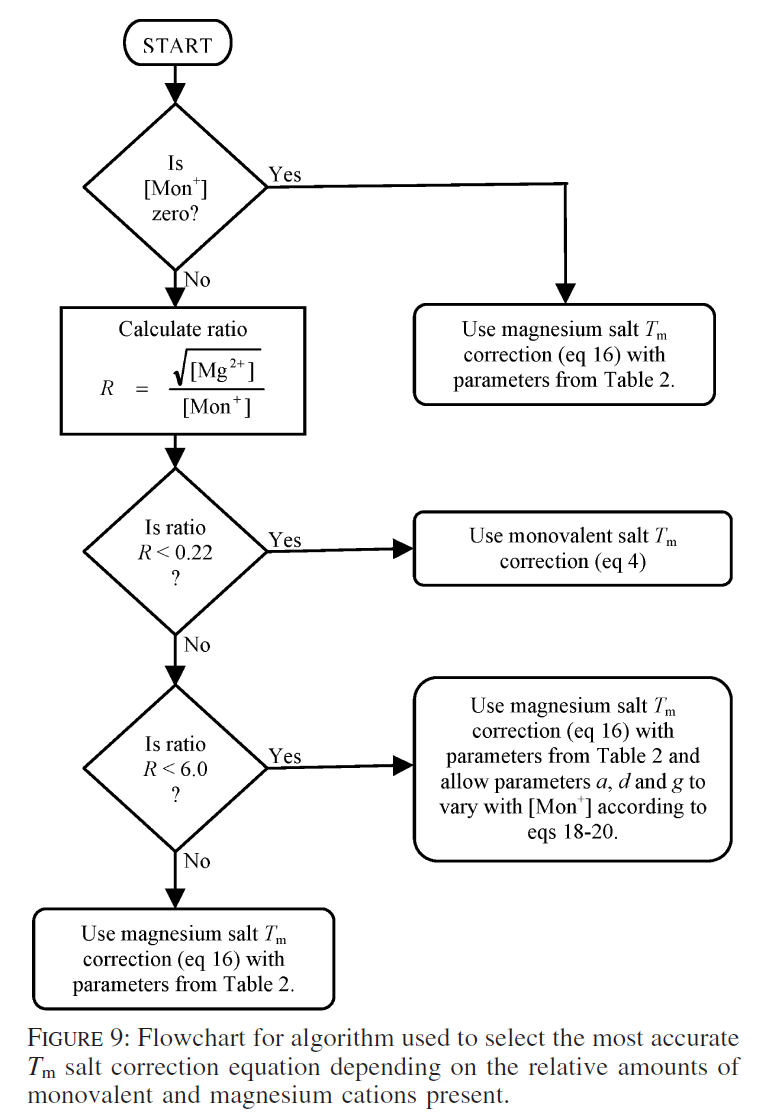

where the equations mentioned (Eq.4 and Eq.16) are the ones we gave in the EDA notebook.\
The complete function implementing this tree is given below for reference (Thanks Claude!), but we will not use it to evaluate things again here since they are already providing MAE results in the paper for the dataset above and the dataset below using their model and prior models as well! (Table 5 in Owc-2008)

In [400]:
import math

def predict_tm_magnesium(tm_1M_Na, Nbp, fGC, Mg_total, Mon_total, dNTP_total=0.0):
    """
    Predict melting temperature (Tm) in buffers containing Mg2+ and monovalent ions.
    
    Based on Owczarzy et al. (2008) Biochemistry 47, 5336-5353.
    Algorithm from Figure 9.

    Parameters
    ----------
    tm_1M_Na   : float  – reference Tm in 1 M Na+ buffer (Celsius)
    Nbp        : int    – number of base pairs
    fGC        : float  – fraction of G·C base pairs (0 to 1)
    Mg_total   : float  – total [Mg2+] in mol/L
    Mon_total  : float  – total monovalent ion concentration [Mon+] in mol/L
                          (sum of [K+] + [Na+] + [Tris+], where [Tris+] ≈ half of [Tris])
    dNTP_total : float  – total dNTP concentration in mol/L (default 0)
                          Free [Mg2+] = Mg_total - dNTP_total (if positive)

    Returns
    -------
    float : predicted Tm in Celsius
    """

    # --- Parameters from Table 2 (constant values) ---
    a0 = 3.92e-5
    b  = -9.11e-6
    c  = 6.26e-5
    d0 = 1.42e-5
    e  = -4.82e-4
    f  = 5.25e-4
    g0 = 8.31e-5

    # Reference Tm in Kelvin
    tm_ref_K = tm_1M_Na + 273.15

    # Compute free [Mg2+] accounting for dNTP chelation
    if dNTP_total > 0:
        free_Mg = Mg_total - dNTP_total
        if free_Mg < 0:
            # Use association constant approach (Ka ~ 3e4 L/mol) when dNTP >= Mg
            Ka = 3e4
            # Solve quadratic: Ka*[Mg]^2 + (Ka*(dNTP-Mg_total)+1)*[Mg] - Mg_total = 0
            A_coef = Ka
            B_coef = Ka * (dNTP_total - Mg_total) + 1
            C_coef = -Mg_total
            discriminant = B_coef**2 - 4 * A_coef * C_coef
            free_Mg = (-B_coef + math.sqrt(discriminant)) / (2 * A_coef)
    else:
        free_Mg = Mg_total

    # --- Figure 9 algorithm: select correction based on R ---

    # Branch 1: no monovalent ions present → use Eq. 16 with Table 2 params
    if Mon_total == 0:
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a0, b, c, d0, e, f, g0)
        return _inv_to_celsius(inv_tm)

    R = math.sqrt(free_Mg) / Mon_total  # units: M^(-1/2)

    # Branch 2: R < 0.22 → monovalent ions dominant, use Eq. 4
    if R < 0.22:
        inv_tm = _eq4(tm_ref_K, Mon_total, fGC)
        return _inv_to_celsius(inv_tm)

    # Branch 3: 0.22 <= R < 6.0 → mixed regime, Eq. 16 with a, d, g varying (Eqs. 18-20)
    elif R < 6.0:
        a = a0 * (0.843 - 0.352 * math.sqrt(Mon_total) * math.log(Mon_total))
        d = d0 * (1.279 - 4.03e-3 * math.log(Mon_total)
                        - 8.03e-3 * (math.log(Mon_total))**2)
        g = g0 * (0.486 - 0.258 * math.log(Mon_total)
                        + 5.25e-3 * (math.log(Mon_total))**3)
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a, b, c, d, e, f, g)
        return _inv_to_celsius(inv_tm)

    # Branch 4: R >= 6.0 → Mg2+ dominant, Eq. 16 with constant Table 2 params
    else:
        inv_tm = _eq16(tm_ref_K, free_Mg, fGC, Nbp, a0, b, c, d0, e, f, g0)
        return _inv_to_celsius(inv_tm)


def _eq16(tm_ref_K, Mg, fGC, Nbp, a, b, c, d, e, f, g):
    """Equation 16: Tm magnesium correction (returns 1/Tm in K^-1)."""
    ln_Mg = math.log(Mg)
    inv_tm = (1.0 / tm_ref_K
              + a
              + b * ln_Mg
              + fGC * (c + d * ln_Mg)
              + (1.0 / (2 * (Nbp - 1))) * (e + f * ln_Mg + g * ln_Mg**2))
    return inv_tm


def _eq4(tm_ref_K, Mon, fGC):
    """Equation 4: monovalent ion Tm correction (returns 1/Tm in K^-1)."""
    ln_Mon = math.log(Mon)
    inv_tm = (1.0 / tm_ref_K
              + (4.29 * fGC - 3.95) * 1e-5 * ln_Mon
              + 9.40e-6 * ln_Mon**2)
    return inv_tm


def _inv_to_celsius(inv_tm_K):
    """Convert 1/Tm (K^-1) to Tm in Celsius."""
    return (1.0 / inv_tm_K) - 273.15


# --- Example from the paper (page 5348) ---
if __name__ == "__main__":
    # 20-bp duplex, fGC = 0.6, 1.5 mM Mg2+, 10 mM Tris-HCl
    # [Tris+] ≈ 5 mM (half of 10 mM Tris is protonated at pH 8.3)
    tm_ref   = 76.3          # Tm in 1 M Na+ (°C)
    Nbp      = 20
    fGC      = 0.600
    Mg       = 0.0015        # 1.5 mM
    Mon      = 0.005         # ~5 mM Tris+
    dNTP     = 0.0

    result = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg, Mon, dNTP)
    print(f"Predicted Tm: {result:.1f} °C  (paper reports 67.9 °C, measured 68.5 °C)")


# Tm_C at monovalent_mM = 1005 mM and Mg2+_mM = 0 mM is used as the reference Tm in 1 M Na+ for all sequences since it is the closest condition to 1 M Na+ in our dataset and it is the only condition in our dataset that has zero Mg2+ concentration, which is required for the reference Tm in 1 M Na+ according to the algorithm from Owczarzy et al. (2008) Biochemistry 47, 5336-5353.
# Copied directly from the paper Table 4 (not part of the training data)
# reference_tm ={'TTCTACCTATGTGAT': np.float64(53.2),
#  'GCAGTGGATGTGAGA': np.float64(62.4),
#  'CAGCCTCGTCGCAGC': np.float64(70.6),
#  'TGATTCTACCTATGTGATTT': np.float64(63.2),
#  'AGCTGCAGTGGATGTGAGAA': np.float64(72.3),
#  'CAGCCTCGTTCGCACAGCCC': np.float64(78.4),
#  'GTTCTATACTCTTGAAGTTGATTAC': np.float64(68.0),
#  'CTGGTCTGGATCTGAGAACTTCAGG': np.float64(75.8),
#  'CAGTGGGCTCCTGGGCGTGCTGGTC': np.float64(83.4),
#  'CTTAAGATATGAGAACTTCAACTAATGTGT': np.float64(72.4),
#  'AGTCTGGTCTGGATCTGAGAACTTCAGGCT': np.float64(80.1),
#  'GACCTGACGTGGACCGCTCCTGGGCGTGGT': np.float64(86.7)}
# This gives MAE=0.6C.

# Tm_C at monovalent_mM = 1.02 M is used as the reference Tm in 1 M Na+ for all sequences since it looks like that is what they did in the analysis shown in table 5 according to the main text of Owc-2008.
# Copied directly from the paper Table 2 of Owc-2004 (not part of the training data)
# reference_tm ={'TTCTACCTATGTGAT': np.float64(53.7),
#  'GCAGTGGATGTGAGA': np.float64(62.3),
#  'CAGCCTCGTCGCAGC': np.float64(72.0),
#  'TGATTCTACCTATGTGATTT': np.float64(64.4),
#  'AGCTGCAGTGGATGTGAGAA': np.float64(73.1),
#  'CAGCCTCGTTCGCACAGCCC': np.float64(78.1),
#  'GTTCTATACTCTTGAAGTTGATTAC': np.float64(67.7),
#  'CTGGTCTGGATCTGAGAACTTCAGG': np.float64(75.6),
#  'CAGTGGGCTCCTGGGCGTGCTGGTC': np.float64(83.4),
#  'CTTAAGATATGAGAACTTCAACTAATGTGT': np.float64(71.8),
#  'AGTCTGGTCTGGATCTGAGAACTTCAGGCT': np.float64(80.6),
#  'GACCTGACGTGGACCGCTCCTGGGCGTGGT': np.float64(86.4)}
# # This given MAE=0.8C as they report in table 5 of Owc-2008.

# # Evaluate the magnesium correction model on the training data using the reference Tm values for each sequence and the corresponding salt conditions, and calculate the MAE of the predictions compared to the actual Tm values in the training data
# magnesium_correction_predictions = []
# for idx, row in owc2008_table4_all.iterrows():
#     seq = row['sequence_5to3']
#     tm_ref = reference_tm.get(seq, None)
#     if tm_ref is not None:
#         Nbp = len(seq)
#         fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
#         Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
#         Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
#         dNTP_total = 0.0  # Assuming no dNTPs in the training data

#         predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
#         magnesium_correction_predictions.append(predicted_tm)
#     else:
#         magnesium_correction_predictions.append(None)  # or some default value if reference Tm is not available

# # Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the training data (only for rows where we have a valid prediction)
# valid_predictions = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions, owc2008_table4_all['Tm_C']) if pred is not None]
# if valid_predictions:
#     preds, actuals = zip(*valid_predictions)
#     mae_magnesium_correction = mean_absolute_error(actuals, preds)
#     print(f"MAE of Magnesium Correction Model on Training Data: {mae_magnesium_correction:.4f} °C")

Predicted Tm: 67.9 °C  (paper reports 67.9 °C, measured 68.5 °C)


The model performance in Owc-2008 is reported in Table 5:
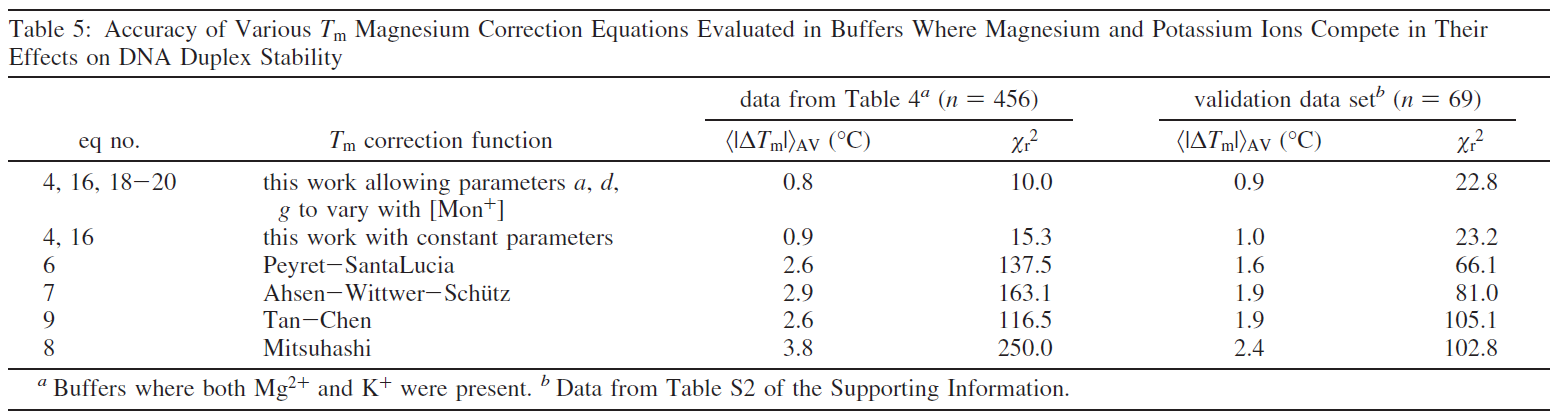
on the two dataseta of Table 4 and Table S2.

**Things to keep in mind regarding these datasets**
1. Data in Table 4 was similarly used to train and develop their model, so it is a fair comparison to use it here as well.
2. We do not compare the whole dataset in Table S2 since some of the data was obtained at different DNA concentrations, check EDA notebook for details. To this end, we *may* need to evaluate their model again on this subset of the dataset of Table S2.

## Testing on the data from Table 4
The data is formatted and has the required features to evluate our model on.

In [401]:
our_model_predictions = our_model.predict(owc2008_table4_all[our_feature_set])
our_model_mae = mean_absolute_error(owc2008_table4_all['Tm_C'], our_model_predictions)
print(f"MAE of our chosen model on the entire training data= {our_model_mae:.1f} °C")
print(f'Comparison to the magnesium correction model: {our_model_mae:.1f} °C vs. 0.8 °C (MAE of magnesium correction model on training data from Table 5 of Owc-2008)')

MAE of our chosen model on the entire training data= 1.3 °C
Comparison to the magnesium correction model: 1.3 °C vs. 0.8 °C (MAE of magnesium correction model on training data from Table 5 of Owc-2008)


**WAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAY better!**

## Testing on the data from Table S2

In [402]:
owc2008_tableS2[['sequence_5to3']+typical_features_no_salt_interaction].sample(10)

,sequence_5to3,monovalent_mM,Mg2+_mM,length_bp,GC_content
36,TTCGCGGATTAGCCCTACGCATCGGTTACAAACGAGGACCTTATGC...,55.0,20.0,60,0.500000
25,TAGCGGACACGGCTGAGCGACCCTGTG,105.0,3.0,27,0.666667
38,CGGAGAGGGACAGCTAGTGCCCCTGTGGGGAGTCGCTTATACAAAG...,55.0,3.0,60,0.550000
31,AGCTGACGCCAAGTCCAAATCTAACCACATGCAAGACACG,55.0,20.0,40,0.500000
26,GCAATAGAAAGAGGAAATAATAGTTTTATATTCGACCTAG,55.0,0.5,40,0.300000
11,CCTCTCTCTCGCCCTT,55.0,0.5,16,0.625000
3,GTAACCGGCATGAA,5.0,20.0,14,0.500000
33,GAATATACCCAGAAGAATTGGTTTGACAGGTTAATTAGAATATTTA...,55.0,3.0,60,0.300000
4,CGCTGCTCACCTGA,55.0,3.0,14,0.642857
19,ATCTCCGAAATACAGAACTA,55.0,125.0,20,0.350000


In [403]:
# Check intersection of sequences in Table S2 with our training data
sequences_in_S2 = set(owc2008_tableS2['sequence_5to3'].unique())
sequences_in_training = set(owc2008_table4_all['sequence_5to3'].unique())
intersection = sequences_in_S2.intersection(sequences_in_training)
print(f"Number of sequences in Table S2: {len(sequences_in_S2)}")
print(f"Number of sequences in training data: {len(sequences_in_training)}")
print(f"Number of sequences in both Table S2 and training data: {len(intersection)}")

Number of sequences in Table S2: 19
Number of sequences in training data: 12
Number of sequences in both Table S2 and training data: 0


In [404]:
# Testing our model on the test data
test_predictions = our_model.predict(owc2008_tableS2[our_feature_set])
test_mae = mean_absolute_error(owc2008_tableS2['Tm_C'], test_predictions)
print(f"MAE of our chosen model on the test data = {test_mae:.1f} °C")
print(f'Comparison to the magnesium correction model: {test_mae:.1f} °C vs. 0.9 °C (MAE of magnesium correction model on test data from Table 5 of Owc-2008)')

MAE of our chosen model on the test data = 8.9 °C
Comparison to the magnesium correction model: 8.9 °C vs. 0.9 °C (MAE of magnesium correction model on test data from Table 5 of Owc-2008)


In [405]:
# Evaluate the model of the paper again on the test data using the reference Tm values for each sequence and the corresponding salt conditions, and calculate the MAE of the predictions compared to the actual Tm values in the test data
magnesium_correction_predictions_test = []
for idx, row in owc2008_tableS2.iterrows():
    seq = row['sequence_5to3']
    # Use column Tm1_C as the referece Tm in 1M Na+.
    tm_ref = row['Tm1_C']
    if tm_ref is not None:
        Nbp = len(seq)
        fGC = (seq.count('G') + seq.count('C')) / Nbp if Nbp > 0 else 0
        Mg_total = row['Mg2+_mM'] * 1e-3  # convert mM to M
        Mon_total = row['monovalent_mM'] * 1e-3  # convert mM to M
        dNTP_total = 0.0  # Assuming no dNTPs in the test data

        predicted_tm = predict_tm_magnesium(tm_ref, Nbp, fGC, Mg_total, Mon_total, dNTP_total)
        magnesium_correction_predictions_test.append(predicted_tm)
    else:
        magnesium_correction_predictions_test.append(None)  # or some default value if reference Tm is not available

# Calculate MAE for the magnesium correction model predictions compared to actual Tm values in the test data (only for rows where we have a valid prediction)
valid_predictions_test = [(pred, actual) for pred, actual in zip(magnesium_correction_predictions_test, owc2008_tableS2['Tm_C']) if pred is not None]
if valid_predictions_test:
    preds_test, actuals_test = zip(*valid_predictions_test)
    mae_magnesium_correction_test = mean_absolute_error(actuals_test, preds_test)
    print(f"MAE of Magnesium Correction Model on Test Data: {mae_magnesium_correction_test:.4f} °C")

MAE of Magnesium Correction Model on Test Data: 0.6150 °C


# References:
1. SantaLucia-1998: J. SantaLucia, A unified view of polymer, dumbbell, and oligonucleotide DNA nearest-neighbor thermodynamics, Proc. Natl. Acad. Sci. U.S.A. 95 (4) 1460-1465, https://doi.org/10.1073/pnas.95.4.1460 (1998).
2. Owc-2004: Effects of Sodium Ions on DNA Duplex Oligomers:  Improved Predictions of Melting Temperatures
Richard Owczarzy, Yong You, Bernardo G. Moreira, Jeffrey A. Manthey, Lingyan Huang, Mark A. Behlke, and Joseph A. Walder
Biochemistry 2004 43 (12), 3537-3554
DOI: https://doi.org/10.1021/bi034621r
3. Owc-2008: Predicting Stability of DNA Duplexes in Solutions Containing Magnesium and Monovalent Cations
Richard Owczarzy, Bernardo G. Moreira, Yong You, Mark A. Behlke, and Joseph A. Walder
Biochemistry 2008 47 (19), 5336-5353
DOI: https://doi.org/10.1021/bi702363u
4. Unz-2010: J.M. Huguet, C.V. Bizarro, N. Forns, S.B. Smith, C. Bustamante, & F. Ritort, Single-molecule derivation of salt dependent base-pair free energies in DNA, Proc. Natl. Acad. Sci. U.S.A. 107 (35) 15431-15436, https://doi.org/10.1073/pnas.1001454107 (2010).
5. Unz-2017: Josep Maria Huguet, Marco Ribezzi-Crivellari, Cristiano Valim Bizarro, Felix Ritort, Derivation of nearest-neighbor DNA parameters in magnesium from single molecule experiments, Nucleic Acids Research, Volume 45, Issue 22, 15 December 2017, Pages 12921–12931, https://doi.org/10.1093/nar/gkx1161

